In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import plotly.express as px
import mysql.connector

print(" Data Analyst Environment Ready")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("Scikit-learn:", sklearn.__version__)

 Data Analyst Environment Ready
Pandas: 2.3.3
NumPy: 2.3.5
Matplotlib: 3.10.0
Seaborn: 0.13.2
Scikit-learn: 1.9.0


In [2]:
import plotly
print("Plotly:", plotly.__version__)

Plotly: 6.8.0


In [3]:
df = pd.read_csv("sales_data_cleaned.csv")

In [4]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,24-02-2003,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,07-05-2003,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,01-07-2003,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,25-08-2003,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10-10-2003,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.shape)

Rows: 2823
Columns: 25
(2823, 25)


In [6]:
for col in df.columns:
    print(col)

ORDERNUMBER
QUANTITYORDERED
PRICEEACH
ORDERLINENUMBER
SALES
ORDERDATE
STATUS
QTR_ID
MONTH_ID
YEAR_ID
PRODUCTLINE
MSRP
PRODUCTCODE
CUSTOMERNAME
PHONE
ADDRESSLINE1
ADDRESSLINE2
CITY
STATE
POSTALCODE
COUNTRY
TERRITORY
CONTACTLASTNAME
CONTACTFIRSTNAME
DEALSIZE


In [7]:
df.dtypes

ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE            object
STATUS               object
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE          object
MSRP                  int64
PRODUCTCODE          object
CUSTOMERNAME         object
PHONE                object
ADDRESSLINE1         object
ADDRESSLINE2         object
CITY                 object
STATE                object
POSTALCODE           object
COUNTRY              object
TERRITORY            object
CONTACTLASTNAME      object
CONTACTFIRSTNAME     object
DEALSIZE             object
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [9]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [10]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [11]:
missing = df.isnull().sum()
missing[missing > 0]

ADDRESSLINE2    2521
STATE           1486
POSTALCODE        76
TERRITORY       1074
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.nunique()

ORDERNUMBER          307
QUANTITYORDERED       58
PRICEEACH           1016
ORDERLINENUMBER       18
SALES               2763
ORDERDATE            252
STATUS                 6
QTR_ID                 4
MONTH_ID              12
YEAR_ID                3
PRODUCTLINE            7
MSRP                  80
PRODUCTCODE          109
CUSTOMERNAME          92
PHONE                 91
ADDRESSLINE1          92
ADDRESSLINE2           9
CITY                  73
STATE                 16
POSTALCODE            73
COUNTRY               19
TERRITORY              3
CONTACTLASTNAME       77
CONTACTFIRSTNAME      72
DEALSIZE               3
dtype: int64

In [14]:
df.memory_usage(deep=True)

Index                  132
ORDERNUMBER          22584
QUANTITYORDERED      22584
PRICEEACH            22584
ORDERLINENUMBER      22584
SALES                22584
ORDERDATE           166557
STATUS              158392
QTR_ID               22584
MONTH_ID             22584
YEAR_ID              22584
PRODUCTLINE         169140
MSRP                 22584
PRODUCTCODE         161224
CUSTOMERNAME        197533
PHONE               171177
ADDRESSLINE1        194703
ADDRESSLINE2         97972
CITY                160214
STATE               116949
POSTALCODE          151356
COUNTRY             152568
TERRITORY           127186
CONTACTLASTNAME     156511
CONTACTFIRSTNAME    155096
DEALSIZE            153826
dtype: int64

In [15]:
df.memory_usage(deep=True).sum()/1024**2

np.float64(2.569000244140625)

In [16]:
numerical = df.select_dtypes(include=['int64','float64']).columns

categorical = df.select_dtypes(include=['object']).columns

In [17]:
print("numerical value column : ",numerical)
print("categorical value column : ",categorical)

numerical value column :  Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'MSRP'],
      dtype='object')
categorical value column :  Index(['ORDERDATE', 'STATUS', 'PRODUCTLINE', 'PRODUCTCODE', 'CUSTOMERNAME',
       'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='object')


In [18]:
df["ORDERDATE"].dtype

dtype('O')

In [19]:
df["ORDERDATE"] = pd.to_datetime(
    df["ORDERDATE"],
    dayfirst=True
)

In [20]:
df["ORDERDATE"].dtype

dtype('<M8[ns]')

In [21]:
df["ORDERDATE"].head()

0   2003-02-24
1   2003-05-07
2   2003-07-01
3   2003-08-25
4   2003-10-10
Name: ORDERDATE, dtype: datetime64[ns]

In [22]:
# Find all text columns
text_columns = df.select_dtypes(include='object').columns

# Remove leading/trailing spaces
for col in text_columns:
    df[col] = df[col].str.strip()

In [23]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [24]:
categorical_columns = [
    "STATUS",
    "PRODUCTLINE",
    "COUNTRY",
    "TERRITORY",
    "DEALSIZE"
]

for col in categorical_columns:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(f"{'='*50}")
    print(df[col].unique())


STATUS
['Shipped' 'Disputed' 'In Process' 'Cancelled' 'On Hold' 'Resolved']

PRODUCTLINE
['Motorcycles' 'Classic Cars' 'Trucks and Buses' 'Vintage Cars' 'Planes'
 'Ships' 'Trains']

COUNTRY
['USA' 'France' 'Norway' 'Australia' 'Finland' 'Austria' 'UK' 'Spain'
 'Sweden' 'Singapore' 'Canada' 'Japan' 'Italy' 'Denmark' 'Belgium'
 'Philippines' 'Germany' 'Switzerland' 'Ireland']

TERRITORY
[nan 'EMEA' 'APAC' 'Japan']

DEALSIZE
['Small' 'Medium' 'Large']


In [25]:
numeric_columns = [
    "QUANTITYORDERED",
    "PRICEEACH",
    "SALES",
    "MSRP"
]

for col in numeric_columns:
    print("=" * 50)
    print(col)
    print("=" * 50)
    print("Minimum :", df[col].min())
    print("Maximum :", df[col].max())
    print()

QUANTITYORDERED
Minimum : 6
Maximum : 97

PRICEEACH
Minimum : 26.88
Maximum : 100.0

SALES
Minimum : 482.13
Maximum : 14082.8

MSRP
Minimum : 33
Maximum : 214



In [26]:
print("Earliest Order :", df["ORDERDATE"].min())
print("Latest Order   :", df["ORDERDATE"].max())

Earliest Order : 2003-01-06 00:00:00
Latest Order   : 2005-05-31 00:00:00


In [27]:
df["MONTH_NAME"] = df["ORDERDATE"].dt.month_name()
df["DAY_NAME"] = df["ORDERDATE"].dt.day_name()
df["YEAR_MONTH"] = df["ORDERDATE"].dt.to_period("M").astype(str)
df[["ORDERDATE", "MONTH_NAME", "DAY_NAME", "YEAR_MONTH"]].head()

,ORDERDATE,MONTH_NAME,DAY_NAME,YEAR_MONTH
0,2003-02-24,February,Monday,2003-02
1,2003-05-07,May,Wednesday,2003-05
2,2003-07-01,July,Tuesday,2003-07
3,2003-08-25,August,Monday,2003-08
4,2003-10-10,October,Friday,2003-10


In [28]:
# 5. Feature Engineering
df["YEAR"] = df["ORDERDATE"].dt.year
df["MONTH_NUMBER"] = df["ORDERDATE"].dt.month
df["MONTH_NAME"] = df["ORDERDATE"].dt.month_name()
df["QUARTER"] = "Q" + df["ORDERDATE"].dt.quarter.astype(str)
df["DAY_NAME"] = df["ORDERDATE"].dt.day_name()
df["YEAR_MONTH"] = df["ORDERDATE"].dt.to_period("M").astype(str)

df[[
    "ORDERDATE",
    "YEAR",
    "MONTH_NUMBER",
    "MONTH_NAME",
    "QUARTER",
    "DAY_NAME",
    "YEAR_MONTH"
]].head()

,ORDERDATE,YEAR,MONTH_NUMBER,MONTH_NAME,QUARTER,DAY_NAME,YEAR_MONTH
0,2003-02-24,2003,2,February,Q1,Monday,2003-02
1,2003-05-07,2003,5,May,Q2,Wednesday,2003-05
2,2003-07-01,2003,7,July,Q3,Tuesday,2003-07
3,2003-08-25,2003,8,August,Q3,Monday,2003-08
4,2003-10-10,2003,10,October,Q4,Friday,2003-10


In [29]:
# Business Question 1
total_revenue = df["SALES"].sum()
print(f"Total Revenue : ${total_revenue:,.2f}")
total_orders = df["ORDERNUMBER"].nunique()
total_customers = df["CUSTOMERNAME"].nunique()
total_products = df["PRODUCTCODE"].nunique()
avg_order_value = df["SALES"].mean()

print(f"Total Revenue      : ${total_revenue:,.2f}")
print(f"Total Orders       : {total_orders}")
print(f"Total Customers    : {total_customers}")
print(f"Unique Products    : {total_products}")
print(f"Average Order Sale : ${avg_order_value:,.2f}")

Total Revenue : $10,032,628.85
Total Revenue      : $10,032,628.85
Total Orders       : 307
Total Customers    : 92
Unique Products    : 109
Average Order Sale : $3,553.89


In [30]:
# Export Cleaned Dataset
df.to_csv("global_sales_cleaned.csv", index=False)
print("Dataset exported successfully.")

Dataset exported successfully.


In [31]:
# Business Overview KPIs
total_revenue = df["SALES"].sum()
total_orders = df["ORDERNUMBER"].nunique()
total_customers = df["CUSTOMERNAME"].nunique()
total_product_lines = df["PRODUCTLINE"].nunique()

print(f"Total Revenue       : ${total_revenue:,.2f}")
print(f"Total Orders        : {total_orders}")
print(f"Total Customers     : {total_customers}")
print(f"Product Lines       : {total_product_lines}")

Total Revenue       : $10,032,628.85
Total Orders        : 307
Total Customers     : 92
Product Lines       : 7


In [32]:
# Revenue Distribution
print(df["SALES"].describe())

count     2823.000000
mean      3553.889072
std       1841.865106
min        482.130000
25%       2203.430000
50%       3184.800000
75%       4508.000000
max      14082.800000
Name: SALES, dtype: float64


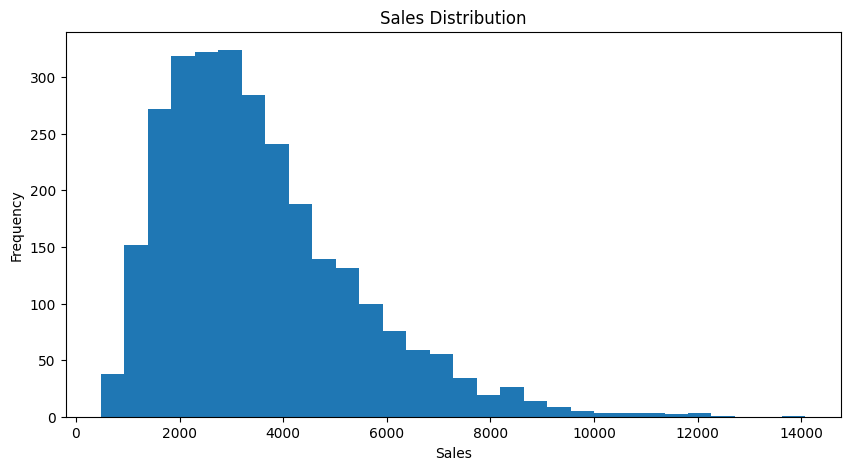

In [33]:
# Sales Distribution
plt.figure(figsize=(10,5))
plt.hist(df["SALES"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

YEAR_ID
2004    4724162.60
2003    3516979.54
2005    1791486.71
Name: SALES, dtype: float64


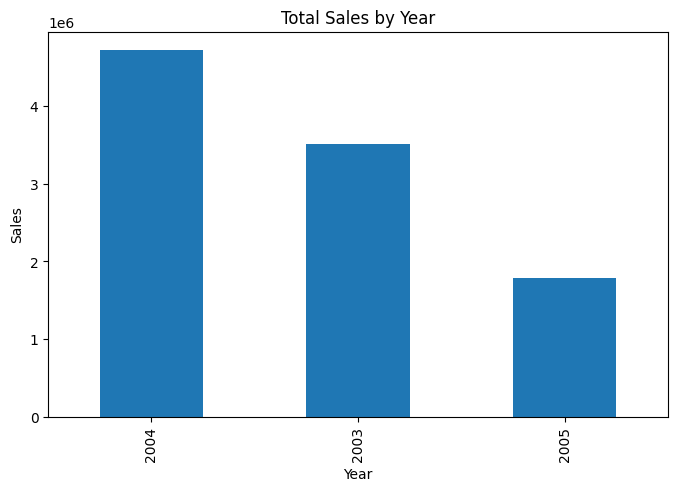

In [34]:
# Sales by Year
sales_by_year = df.groupby("YEAR_ID")["SALES"].sum().sort_values(ascending=False)
print(sales_by_year)
plt.figure(figsize=(8,5))
sales_by_year.plot(kind="bar")
plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

MONTH_NAME
January       785874.44
February      810441.90
March         754501.39
April         669390.96
May           923972.56
June          454756.78
July          514875.97
August        659310.57
September     584724.27
October      1121215.22
November     2118885.67
December      634679.12
Name: SALES, dtype: float64


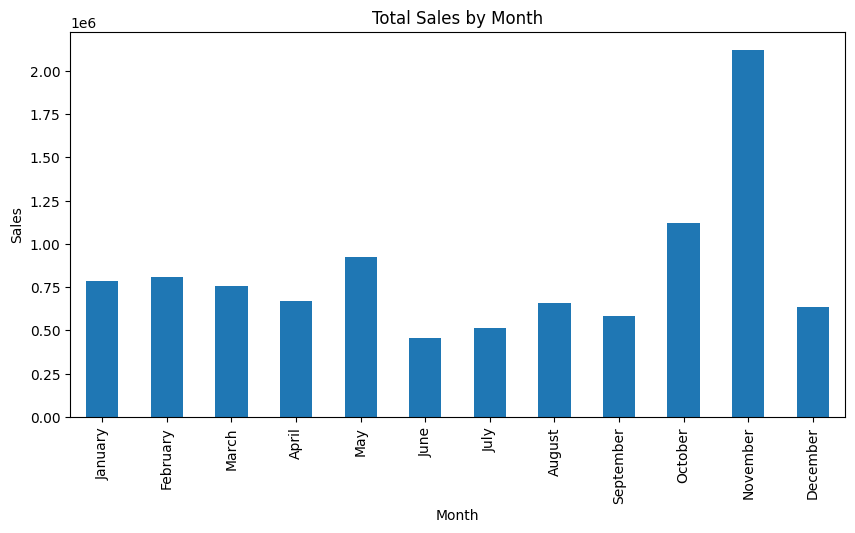

In [35]:
# Sales by Month
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

sales_by_month = (
    df.groupby("MONTH_NAME")["SALES"]
      .sum()
      .reindex(month_order)
)

print(sales_by_month)

plt.figure(figsize=(10,5))
sales_by_month.plot(kind="bar")

plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

QTR_ID
1    2350817.73
2    2048120.30
3    1758910.81
4    3874780.01
Name: SALES, dtype: float64


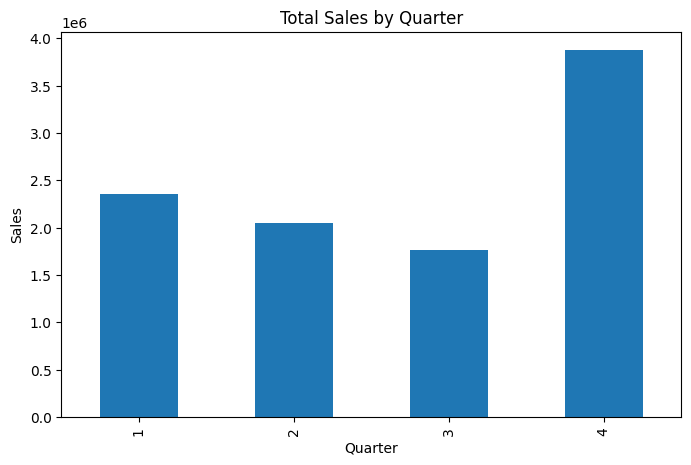

In [36]:
# sales by quarter
sales_by_quarter = df.groupby("QTR_ID")["SALES"].sum()
print(sales_by_quarter)
plt.figure(figsize=(8,5))
sales_by_quarter.plot(kind="bar")
plt.title("Total Sales by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.show()

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64


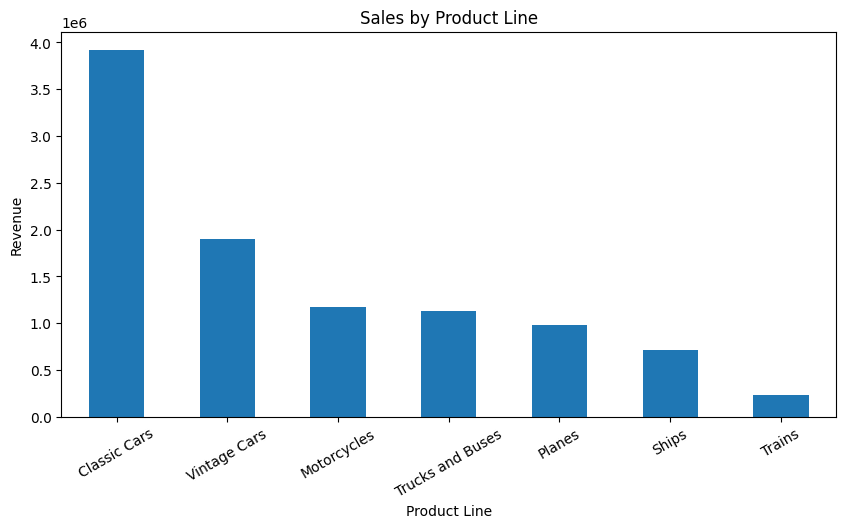

In [37]:
# Sales by Product Line
sales_by_product = (
    df.groupby("PRODUCTLINE")["SALES"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_product)

plt.figure(figsize=(10,5))
sales_by_product.plot(kind="bar")

plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.show()

PRODUCTLINE
Classic Cars        33992
Vintage Cars        21069
Motorcycles         11663
Trucks and Buses    10777
Planes              10727
Ships                8127
Trains               2712
Name: QUANTITYORDERED, dtype: int64


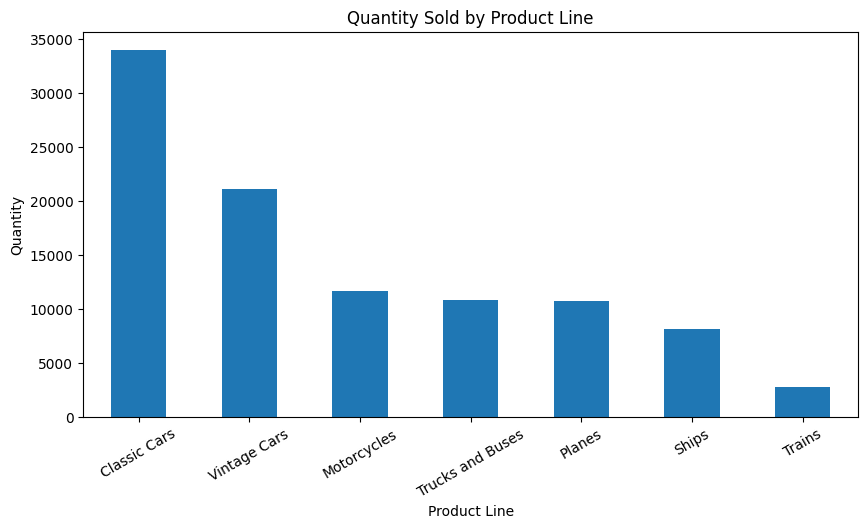

In [38]:
# Quantity Sold by Product Line
quantity_by_product = (
    df.groupby("PRODUCTLINE")["QUANTITYORDERED"]
      .sum()
      .sort_values(ascending=False)
)
print(quantity_by_product)
plt.figure(figsize=(10,5))
quantity_by_product.plot(kind="bar")
plt.title("Quantity Sold by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Quantity")
plt.xticks(rotation=30)
plt.show()

PRODUCTLINE
Classic Cars        39.07
Vintage Cars        18.97
Motorcycles         11.63
Trucks and Buses    11.24
Planes               9.72
Ships                7.12
Trains               2.26
Name: SALES, dtype: float64


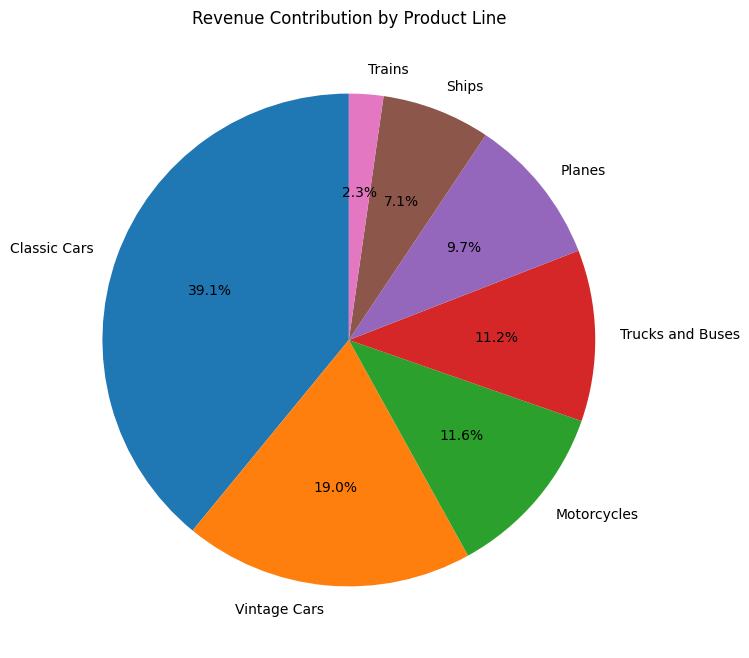

In [39]:
# Revenue Contribution by Product Line
product_share = (
    df.groupby("PRODUCTLINE")["SALES"]
      .sum()
      .sort_values(ascending=False)
)
share = (product_share / product_share.sum()) * 100
print(share.round(2))
plt.figure(figsize=(8,8))
plt.pie(
    share,
    labels=share.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Revenue Contribution by Product Line")
plt.show()

CUSTOMERNAME
Euro Shopping Channel           912294.11
Mini Gifts Distributors Ltd.    654858.06
Australian Collectors, Co.      200995.41
Muscle Machine Inc              197736.94
La Rochelle Gifts               180124.90
Dragon Souveniers, Ltd.         172989.68
Land of Toys Inc.               164069.44
The Sharp Gifts Warehouse       160010.27
AV Stores, Co.                  157807.81
Anna's Decorations, Ltd         153996.13
Name: SALES, dtype: float64


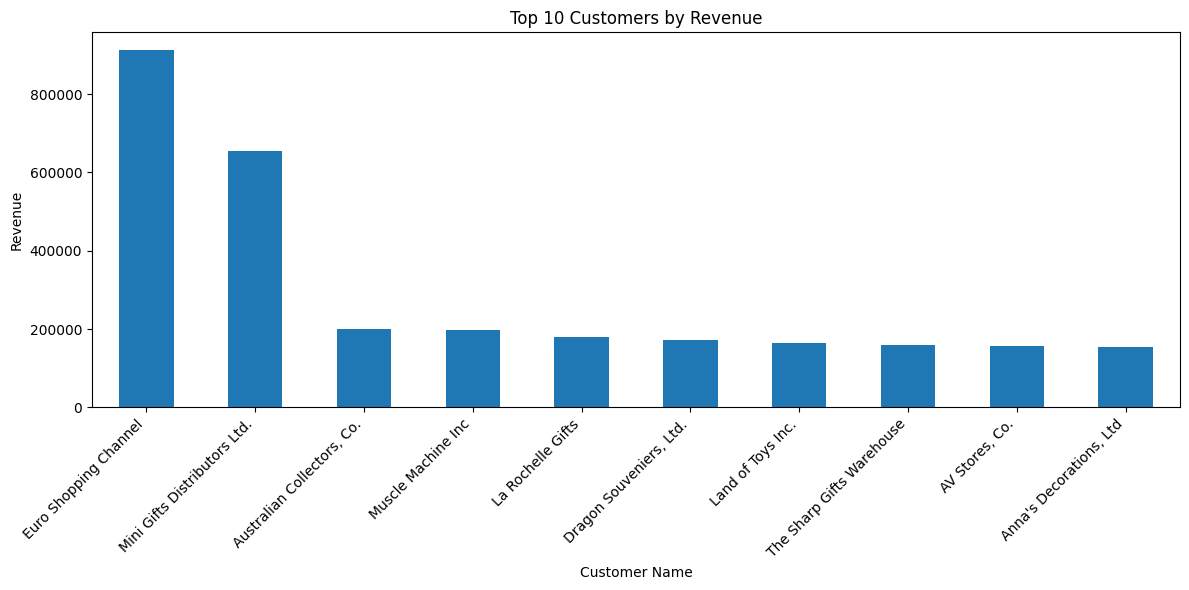

In [40]:
 #Top 10 Customers by Revenue
top_customers = (
    df.groupby("CUSTOMERNAME")["SALES"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

plt.figure(figsize=(12,6))
top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer Name")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [41]:
# Top 10 Customer Revenue Contribution
customer_share = (top_customers / df["SALES"].sum()) * 100
print(customer_share.round(2))

CUSTOMERNAME
Euro Shopping Channel           9.09
Mini Gifts Distributors Ltd.    6.53
Australian Collectors, Co.      2.00
Muscle Machine Inc              1.97
La Rochelle Gifts               1.80
Dragon Souveniers, Ltd.         1.72
Land of Toys Inc.               1.64
The Sharp Gifts Warehouse       1.59
AV Stores, Co.                  1.57
Anna's Decorations, Ltd         1.53
Name: SALES, dtype: float64


COUNTRY
USA            3627982.83
Spain          1215686.92
France         1110916.52
Australia       630623.10
UK              478880.46
Italy           374674.31
Finland         329581.91
Norway          307463.70
Singapore       288488.41
Denmark         245637.15
Canada          224078.56
Germany         220472.09
Sweden          210014.21
Austria         202062.53
Japan           188167.81
Switzerland     117713.56
Belgium         108412.62
Philippines      94015.73
Ireland          57756.43
Name: SALES, dtype: float64


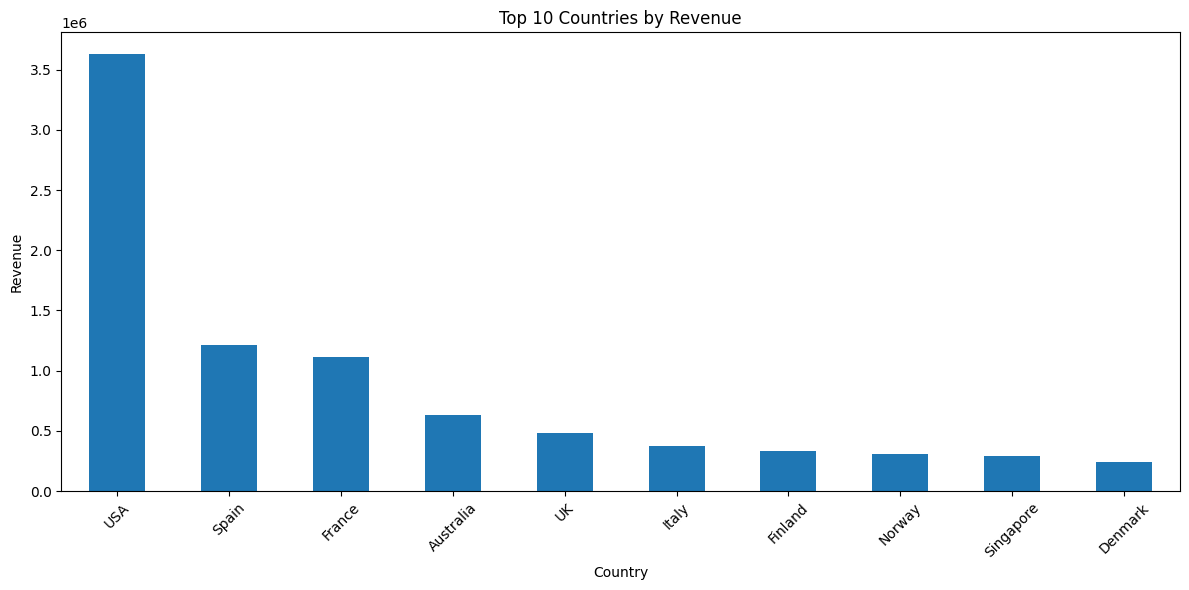

In [42]:
# Sales by Country
sales_by_country = (
    df.groupby("COUNTRY")["SALES"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_country)

plt.figure(figsize=(12,6))
sales_by_country.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [43]:
# Revenue Share by Country
country_share = (sales_by_country / sales_by_country.sum()) * 100
print(country_share.round(2))

COUNTRY
USA            36.16
Spain          12.12
France         11.07
Australia       6.29
UK              4.77
Italy           3.73
Finland         3.29
Norway          3.06
Singapore       2.88
Denmark         2.45
Canada          2.23
Germany         2.20
Sweden          2.09
Austria         2.01
Japan           1.88
Switzerland     1.17
Belgium         1.08
Philippines     0.94
Ireland         0.58
Name: SALES, dtype: float64


In [44]:
# Export Final Dataset
df.to_csv("global_sales_cleaned.csv", index=False)
print("Final cleaned dataset exported successfully!")

Final cleaned dataset exported successfully!
